In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from utils import preprocess_data

RANDOM_STATE = 36

# Loading Data

In [60]:
df_train = pd.read_csv('data/train.csv') # With Target
df_test= pd.read_csv('data/test.csv') # No Target
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Preprocessing Data

In [61]:
X_train = df_train.drop(columns='Transported')
y_train = df_train['Transported']

X_train, median = preprocess_data(X_train)
X_test, _ = preprocess_data(
    df_test,
    median,
    X_train.columns
)

print(X_train.shape, X_test.shape)
X_test.head()


(8693, 27) (4277, 27)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpendings,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown,...,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_Unknown,CabinSide_S,CabinSide_Unknown
0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,19.0,0.0,9.0,0.0,2823.0,0.0,2832.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,31.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
3,38.0,0.0,6652.0,0.0,181.0,585.0,7418.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,20.0,10.0,0.0,635.0,0.0,0.0,645.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


# Train Val Splitting Train Data

In [ ]:
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_cv.shape, y_train.shape, y_cv.shape)

(6954, 27) (1739, 27) (6954,) (1739,)


# Training Tree Model

In [ ]:
learning_rates = [0.3, 0.2, 0.15, 0.1, 0.08, 0.05, 0.03, 0.02, 0.01]
best_train_loss = []
best_cv_loss = []

for rate in learning_rates:
    model = XGBClassifier(
        n_estimators = 500,
        learning_rate = rate,
        max_depth = 5,
        subsample = 0.8,
        colsample_bytree =0.5,
        random_state = RANDOM_STATE,
        eval_metric = "logloss",
        early_stopping_rounds=20
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_cv, y_cv)],
        verbose=False
    )
    
    results = model.evals_result()
    train_loss = results['validation_0']['logloss']
    cv_loss = results['validation_1']['logloss']
    
    best_train_loss.append(min(train_loss))
    best_cv_loss.append(min(cv_loss))


# Predicting
ypred_train = model.predict(X_train)
ypred_cv = model.predict(X_cv)

LR=0.30 | Train=0.3121 | CV=0.4145 | Trees=40
LR=0.20 | Train=0.3337 | CV=0.4155 | Trees=43
LR=0.15 | Train=0.3071 | CV=0.4106 | Trees=107
LR=0.10 | Train=0.3220 | CV=0.4120 | Trees=128
LR=0.08 | Train=0.3258 | CV=0.4137 | Trees=157
LR=0.05 | Train=0.2986 | CV=0.4087 | Trees=395
LR=0.03 | Train=0.3233 | CV=0.4100 | Trees=493
LR=0.02 | Train=0.3489 | CV=0.4139 | Trees=493
LR=0.01 | Train=0.3818 | CV=0.4255 | Trees=500


In [84]:
print(best_cv_loss)
learning_rates[np.argmin(best_cv_loss)]

[0.41453096846331716, 0.41551986326853935, 0.41055664749726656, 0.4119845593838409, 0.4136951408519718, 0.4087137031099328, 0.4099939497020257, 0.4138902634979521, 0.42553991627198756]


0.05

# Evaluating Predictions

### Evaluating: Train set Predictions

In [64]:
# accuracy_score_train =  accuracy_score(y_train, ypred_train)
# confusion_matrix_train =  confusion_matrix(y_train, ypred_train)
# classification_report_train =  classification_report(y_train, ypred_train)

# print('Accuracy:', accuracy_score_train)
# print(confusion_matrix_train)
# print(classification_report_train)

### Evaluating: Test set Predictions

In [70]:
accuracy_score_cv =  accuracy_score(y_cv, ypred_cv)
confusion_matrix_cv =  confusion_matrix(y_cv, ypred_cv)
classification_report_cv =  classification_report(y_cv, ypred_cv)

print('Accuracy:', accuracy_score_cv)
print(confusion_matrix_cv)
print(classification_report_cv)


Accuracy: 0.7958596894767107
[[637 210]
 [145 747]]
              precision    recall  f1-score   support

       False       0.81      0.75      0.78       847
        True       0.78      0.84      0.81       892

    accuracy                           0.80      1739
   macro avg       0.80      0.79      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [72]:
print(train_loss)

[[0.6007804509326237, 0.5463917542282178, 0.5131710106086416, 0.48565071404863097, 0.4612270335069257, 0.44319296566737876, 0.43484230926980877, 0.42867300552062887, 0.41921614671674035, 0.41456759837877916, 0.40835761872214216, 0.4022832719321468, 0.39749717369926346, 0.393597088710785, 0.3871909025785997, 0.3838810620158225, 0.38147102777281255, 0.3796221614062094, 0.37742899611968894, 0.37345494097353166, 0.3711051678643657, 0.36903459814763906, 0.3676174795202834, 0.365357083503571, 0.36391391568687426, 0.3629200410443099, 0.3621926721032134, 0.35930260783434703, 0.3571736353684832, 0.35385846672780535, 0.35223734629450826, 0.3514272079777336, 0.350296038616857, 0.3488308866656628, 0.3470062448056953, 0.34620754956123806, 0.345267197981661, 0.3441363486763529, 0.34195230292942785, 0.3411433837766896, 0.3403026444435354, 0.33784694737969345, 0.33644259533215554, 0.33401425717021554, 0.33187595939343456, 0.3307067850024887, 0.33032202681404654, 0.32884436335645434, 0.325859960124237,

ValueError: Input could not be cast to an at-least-1D NumPy array

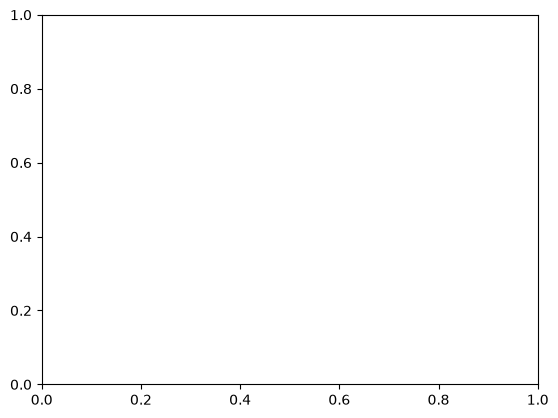

In [ ]:
plt.plot(train_loss, label='Training Loss')
plt.plot(cv_loss, label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Number of Trees')
plt.ylabel('Loss')
plt.legend()
plt.grid(0.8)